In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [12]:
data = pd.read_csv('vit_papers.csv', header = 1)
data.head()

,Short Name Identifier,Year,Local,Global,Post-hoc,Ante-hoc,Model-specific,Model-class-specific,Model-agnostic,Class-specific,...,Prototype-based,Concept-based,Weight-Input-Alignment,Masking-based,Connectivity Constraints,Fantozzi,Kashefi,Stassin,Unnamed: 34,Citation Key
0,Transformer Attribution,2021.0,x,NaN,x,NaN,NaN,x,NaN,x,...,NaN,NaN,NaN,NaN,NaN,x,x,x,x,cheferTransformerInterpretabilityAttention2021
1,GAE,2021.0,x,NaN,x,NaN,NaN,x,NaN,x,...,NaN,NaN,NaN,NaN,NaN,x,x,x,x,cheferGenericAttentionmodelExplainability2021
2,IA-RED2,2021.0,x,NaN,NaN,x,NaN,x,NaN,NaN,...,NaN,NaN,NaN,x,NaN,NaN,x,NaN,x,panIARED2InterpretabilityAwareRedundancy2021
3,TAM,2021.0,x,NaN,x,NaN,NaN,x,NaN,x,...,NaN,NaN,NaN,NaN,NaN,x,x,NaN,x,yuanExplainingInformationFlow2021
4,RELAX,2021.0,x,NaN,x,NaN,NaN,NaN,x,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,x,wickstromRELAXRepresentationLearning2023


In [13]:
data = data.replace({'NaN': 0, " " : 0, "?" : 0, 'x': 1}).fillna(0)

for col in data.columns:
    try:
        numeric_col = pd.to_numeric(data[col], errors='raise') # attempts to convert the column to numeric, raises an error if it fails
        if (numeric_col % 1 == 0).all(): # checks if all values are integers
            data[col] = numeric_col.astype(int)
        else:
            data[col] = numeric_col
    except (ValueError, TypeError) as e:
        # If conversion fails, print the error message and the column name
        print(f"Could not convert column '{col}' to numeric. Error: {e}")
        print(col)
        pass

data.head()

Could not convert column 'Short Name Identifier' to numeric. Error: Unable to parse string "Transformer Attribution" at position 0
Short Name Identifier
Could not convert column 'Citation Key' to numeric. Error: Unable to parse string "cheferTransformerInterpretabilityAttention2021" at position 0
Citation Key


C:\Users\cwinklm\AppData\Local\Temp\ipykernel_26020\3123184628.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data = data.replace({'NaN': 0, " " : 0, "?" : 0, 'x': 1}).fillna(0)


,Short Name Identifier,Year,Local,Global,Post-hoc,Ante-hoc,Model-specific,Model-class-specific,Model-agnostic,Class-specific,...,Prototype-based,Concept-based,Weight-Input-Alignment,Masking-based,Connectivity Constraints,Fantozzi,Kashefi,Stassin,Unnamed: 34,Citation Key
0,Transformer Attribution,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,0,1,1,1,1,cheferTransformerInterpretabilityAttention2021
1,GAE,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,0,1,1,1,1,cheferGenericAttentionmodelExplainability2021
2,IA-RED2,2021,1,0,0,1,0,1,0,0,...,0,0,0,1,0,0,1,0,1,panIARED2InterpretabilityAwareRedundancy2021
3,TAM,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,0,1,1,0,1,yuanExplainingInformationFlow2021
4,RELAX,2021,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,wickstromRELAXRepresentationLearning2023


In [14]:
print(data.dtypes)

Short Name Identifier       object
Year                         int64
Local                        int64
Global                       int64
Post-hoc                     int64
Ante-hoc                     int64
Model-specific               int64
Model-class-specific         int64
Model-agnostic               int64
Class-specific               int64
Class-agnostic               int64
Prediction                   int64
Concept                      int64
Embedding                    int64
Patch Interactions           int64
Feature Relevance            int64
Scalar                       int64
Examples                     int64
Graph                        int64
Contrastive                  int64
Text                         int64
Attention                    int64
Activation                   int64
Perturbations                int64
Relevance                    int64
Gradient                     int64
Prototype-based              int64
Concept-based                int64
Weight-Input-Alignme

In [ ]:
print(data.columns)

methods = ['Local', 'Global', 'Post-hoc',
       'Ante-hoc', 'Model-specific', 'Model-class-specific', 'Model-agnostic',
       'Class-specific', 'Class-agnostic', 'Prediction', 'Concept',
       'Embedding', 'Patch Interactions', 'Feature Relevance', 'Scalar',
       'Examples', 'Graph', 'Model Component', 'Contrastive', 'Text',
       'Attention', 'Activation', 'Perturbations', 'Relevance', 'Gradient',
       'Prototype-based', 'Concept-based', 'Weight-Input-Alignment',
       'Masking-based', 'Connectivity Constraints']
print(f"{len(methods)} methods  ")

taxonomy = {"Scope": ['Local', 'Global'],
	 'Stage': ['Post-hoc', 'Ante-hoc'],
       'Model Compatability': ['Model-specific', 'Model-class-specific', 'Model-agnostic'],
       'Class-specificity': ['Class-specific', 'Class-agnostic'],
       'Explanation Target': ['Prediction', 'Concept','Embedding', 'Patch Interactions'],
       'Result': [ 'Feature Relevance', 'Scalar', 'Examples', 'Graph', 'Contrastive', 'Text'], # 'Model Component',
       'Functioning': ['Activation', 'Attention', 'Perturbations', 'Relevance', 'Gradient'],
       'Architectural Mechanisms': ['Prototype-based', 'Concept-based', 'Weight-Input-Alignment',
       'Masking-based', 'Connectivity Constraints']}

for key, value in taxonomy.items():
    print(f"{key}: {len(value)} methods")

Index(['Short Name Identifier', 'Year', 'Local', 'Global', 'Post-hoc',
       'Ante-hoc', 'Model-specific', 'Model-class-specific', 'Model-agnostic',
       'Class-specific', 'Class-agnostic', 'Prediction', 'Concept',
       'Embedding', 'Patch Interactions', 'Feature Relevance', 'Scalar',
       'Examples', 'Graph', 'Contrastive', 'Text', 'Attention', 'Activation',
       'Perturbations', 'Relevance', 'Gradient', 'Prototype-based',
       'Concept-based', 'Weight-Input-Alignment', 'Masking-based',
       'Connectivity Constraints', 'Fantozzi', 'Kashefi', 'Stassin',
       'Unnamed: 34', 'Citation Key'],
      dtype='object')
30 methods  
Scope: 2 methods
Stage: 2 methods
Model Compatability: 3 methods
Class-specificity: 2 methods
Explanation Target: 4 methods
Result: 7 methods
Functioning: 5 methods
Architectural Mechanisms: 5 methods


In [16]:
print(data["Year"].unique())
data = data.query('Year >= 2019')
print(data["Year"].unique())


data["ShortYear"] = data["Year"]-2000
print(data["ShortYear"].unique())

[2021 2022 2023 2024 2025    0    5    9   14   18   46]
[2021 2022 2023 2024 2025]
[21 22 23 24 25]


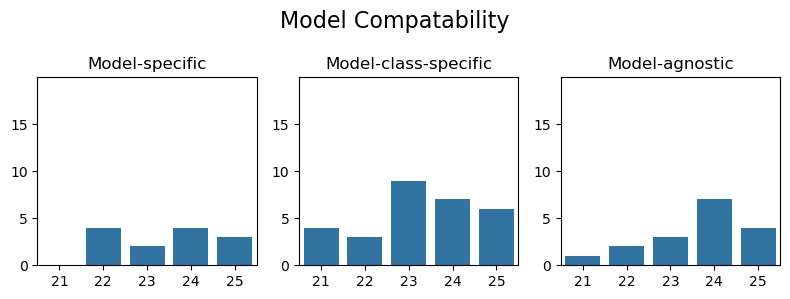

In [9]:


# for sup_tax in taxonomy.keys():
#     print(f"{sup_tax}: {taxonomy[sup_tax]}")
sup_tax = "Model Compatability"

plt.figure(figsize=(8,3))
for m_idx, method in enumerate(taxonomy[sup_tax]):
    plt.subplot(1, len(taxonomy[sup_tax]), m_idx+1)

    sns.barplot(x='ShortYear', y=method, data=data, errorbar=None, estimator='sum')
    plt.ylabel('')
    # if m_idx == 0:
    #     plt.ylabel('Number of papers')
    #     plt.ylim(0, 30)
    #     plt.yticks([0, 5, 10, 15, 20, 25])
    # else: 
    #     plt.ylim(0, 10)
    #     plt.yticks([0, 2, 4, 6, 8])

    plt.ylim(0, 20)
    plt.yticks([0, 5, 10, 15,])


    plt.title(method)   
    plt.xlabel('')

    plt.suptitle(f"{sup_tax}", size=16  )
    plt.tight_layout()

    plt.savefig(f"{sup_tax}_barplot.pdf", dpi=300)

Local
Global
Post-hoc
Ante-hoc
Model-specific
Model-class-specific
Model-agnostic
Class-specific
Class-agnostic
Prediction
Concept
Embedding
Patch Interactions
Feature Relevance
Scalar
Examples
Graph
Model Component


ValueError: Could not interpret value `Model Component` for `y`. An entry with this name does not appear in `data`.

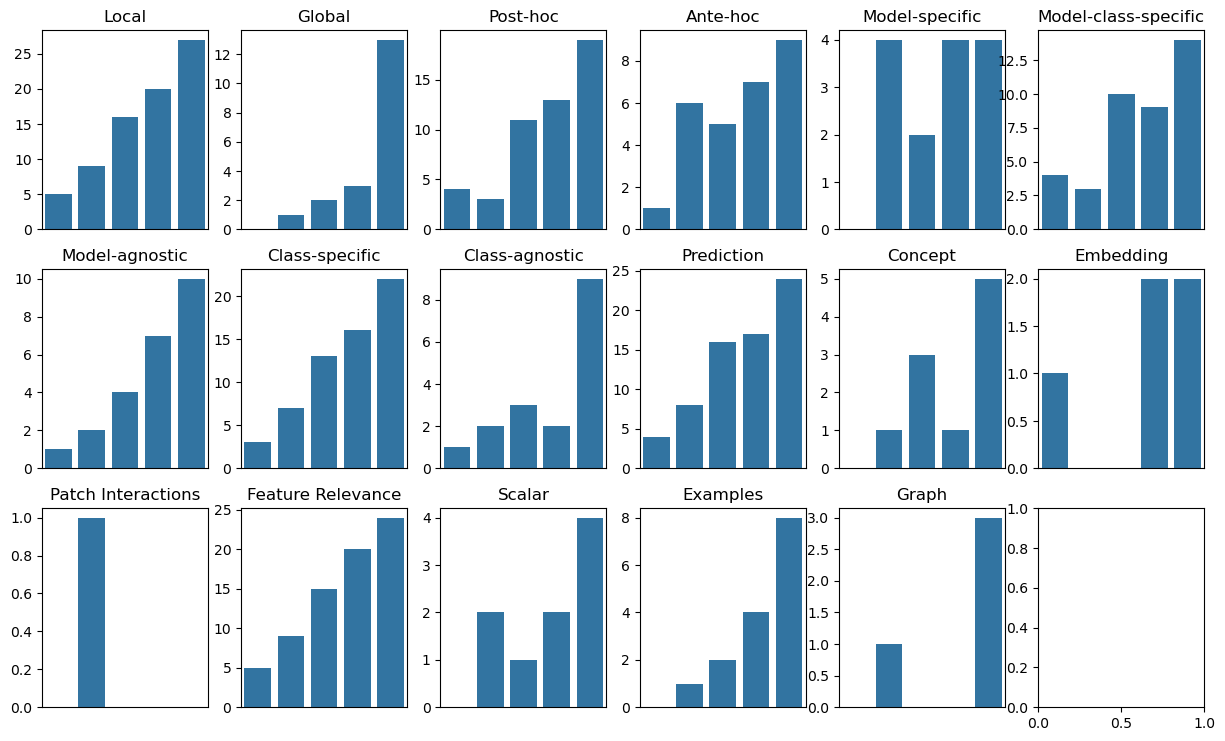

In [17]:
plt.figure(figsize=(15,15))

for m_idx, method in enumerate(methods):
    print(method)
    plt.subplot(5, 6, m_idx + 1)

    sns.barplot(x='ShortYear', y=method, data=data, errorbar=None, estimator='sum')

    if m_idx < 24:
        
        plt.xticks([])

    plt.title(method)   
    plt.ylabel('')
    plt.xlabel('')

    plt.savefig(f"all_barplot.png", dpi=300)

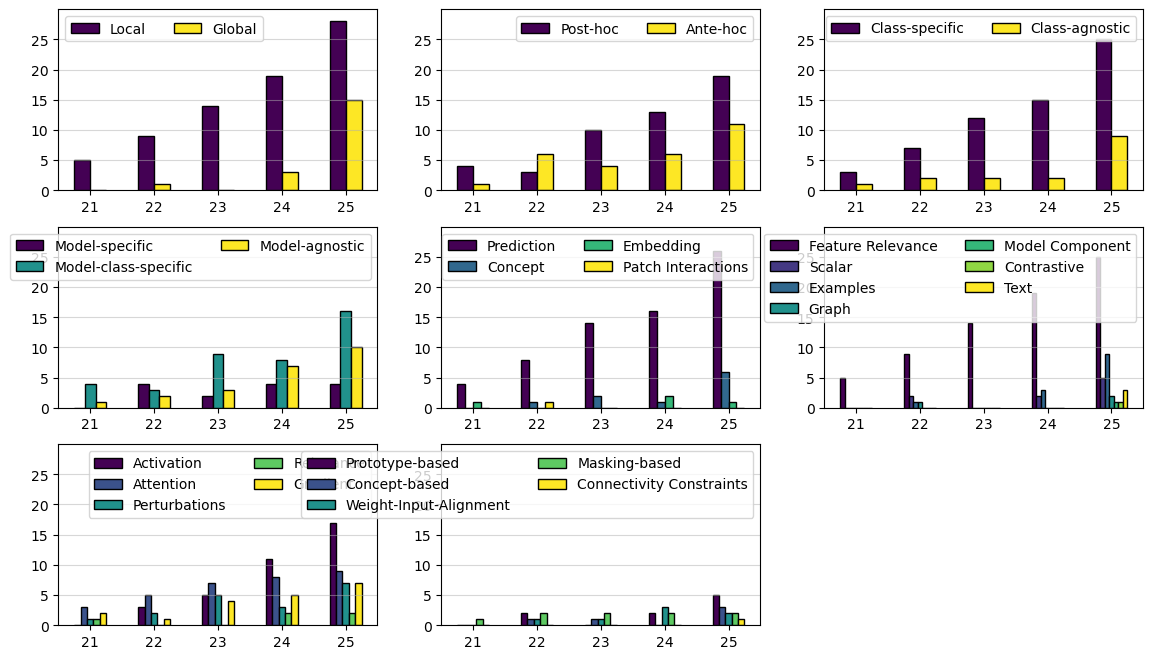

: 

: 

: 

In [ ]:
fig = plt.figure(figsize=(14, 8))

tax_keys = ['Scope', 'Stage', 'Class-specificity', 'Model Compatability', 'Explanation Target', 'Result', 'Functioning', 'Architectural Mechanisms']


for tax_idx, sup_tax in enumerate(tax_keys):

    ax = plt.subplot(3,3, tax_idx+1)
    cols = [st for st in taxonomy[sup_tax]] + ['ShortYear']

    my_data = data[cols]
    my_data = my_data.groupby('ShortYear').sum()


    my_data.plot(kind='bar', colormap='viridis', edgecolor='black', linewidth=1, ax=ax)
    plt.xlabel("")
    plt.xticks(rotation=0)
    plt.grid(alpha=0.5, axis='y')

    plt.ylim(0, 30)
    plt.yticks([0, 5, 10, 15, 20, 25])

    plt.legend(ncol=2)

    plt.savefig(f"all_barplot_grouped.png", dpi=300)



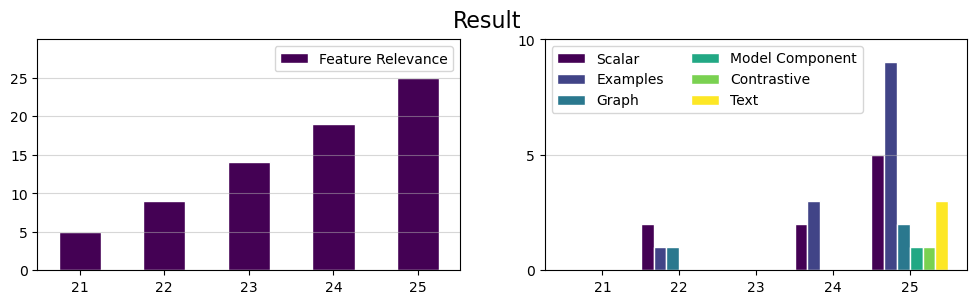

: 

: 

: 

In [ ]:
fig = plt.figure(figsize=(12,3))

sup_tax = "Result"



ax = plt.subplot(121)
cols = ['Feature Relevance', 'ShortYear']

my_data = data[cols]
my_data = my_data.groupby('ShortYear').sum()

my_data.plot(kind='bar', colormap='viridis', edgecolor='white', linewidth=1, ax=ax)
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(alpha=0.5, axis='y')

plt.ylim(0, 30)
plt.yticks([0, 5, 10, 15, 20, 25])

plt.legend(ncol=2)


ax = plt.subplot(122)
cols = [st for st in taxonomy[sup_tax]] + ['ShortYear']
cols.remove('Feature Relevance')

my_data = data[cols]
my_data = my_data.groupby('ShortYear').sum()

my_data.plot(kind='bar', colormap='viridis', edgecolor='white', linewidth=1, ax=ax, width=1   )
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(alpha=0.5, axis='y')

plt.ylim(0, 10)
plt.yticks([0, 5, 10])

plt.legend(ncol=2)

plt.suptitle(f"{sup_tax}", size=16  )

plt.savefig(f"Result_barplot_grouped.png", dpi=300)


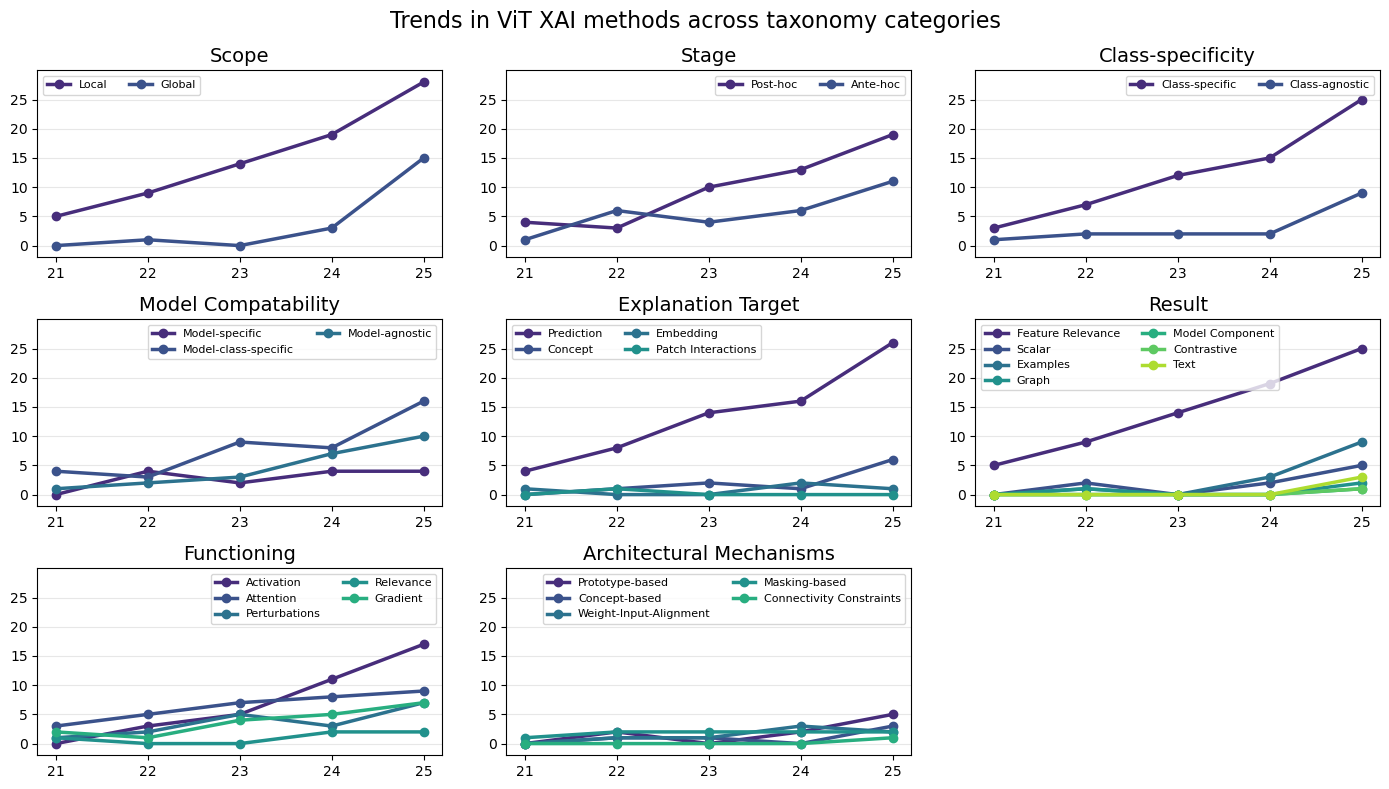

: 

: 

: 

In [ ]:


plt.figure(figsize=(14, 8))

tax_keys = ['Scope', 'Stage', 'Class-specificity', 'Model Compatability', 'Explanation Target', 'Result', 'Functioning', 'Architectural Mechanisms']

for tax_idx, sup_tax in enumerate(tax_keys):
    #print(f"{sup_tax}: {taxonomy[sup_tax]}")
    with sns.color_palette("viridis", n_colors=7):
        for m_idx, method in enumerate(taxonomy[sup_tax]):

            plt.subplot(3,3, tax_idx+1)

            data[method].groupby(data["ShortYear"]).sum().plot(kind='line', marker='o', label=method, lw=2.5)
            plt.ylim(-2, 30)
            plt.yticks([0, 5, 10, 15, 20, 25])
            plt.ylabel('')
            plt.xticks([21, 22, 23, 24, 25])
            plt.xlabel('')

            plt.legend(ncol=2, fontsize=8)
            
            plt.grid(alpha = 0.3, which='both', axis='y')
            plt.title(f"{sup_tax}", size=14  )
plt.suptitle(f"Trends in ViT XAI methods across taxonomy categories", size=16  )
plt.tight_layout()

plt.savefig(f"trend_lineplot.png", dpi=300)

In [ ]:
data[method].groupby(data["ShortYear"]).sum()

ShortYear
21    0
22    0
23    0
24    0
25    1
Name: Connectivity Constraints, dtype: int64

: 

: 

: 

In [ ]:
data.head()


,Short Name Identifier,Year,Local,Global,Post-hoc,Ante-hoc,Model-specific,Model-class-specific,Model-agnostic,Class-specific,...,Prototype-based,Concept-based,Weight-Input-Alignment,Masking-based,Connectivity Constraints,Fantozzi,Kashefi,Stassin,Citation Key,ShortYear
0,Transformer Attribution,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,0,1,1,1,cheferTransformerInterpretabilityAttention2021,21
1,GAE,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,0,1,1,1,cheferGenericAttentionmodelExplainability2021,21
2,IA-RED2,2021,1,0,0,1,0,1,0,0,...,0,0,0,1,0,0,1,0,panIARED2InterpretabilityAwareRedundancy2021,21
3,TAM,2021,1,0,1,0,0,1,0,1,...,0,0,0,0,0,1,1,0,yuanExplainingInformationFlow2021,21
4,RELAX,2021,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,wickstromRELAXRepresentationLearning2023,21


: 

: 

: 

In [ ]:
import matplotlib.pyplot as plt

# create data
size_of_groups=[12,11,3,30]

# Create a pieplot
plt.pie(size_of_groups)

# add a circle at the center to transform it in a donut chart
my_circle=plt.Circle( (0,0), 0.7, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)

plt.show()

: 

: 

: 